# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [3]:
# Import the library
from PIL import Image
import numpy as np

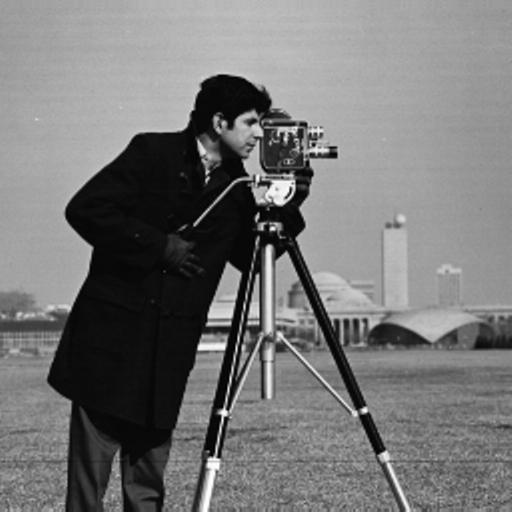

In [4]:
# ── Load image ────────────────────────────────────
img = Image.open('cameraman.jpg')
display(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [5]:
# Get the size of the image

w , h = img.size

# scaling factors

cx , cy = 2,2


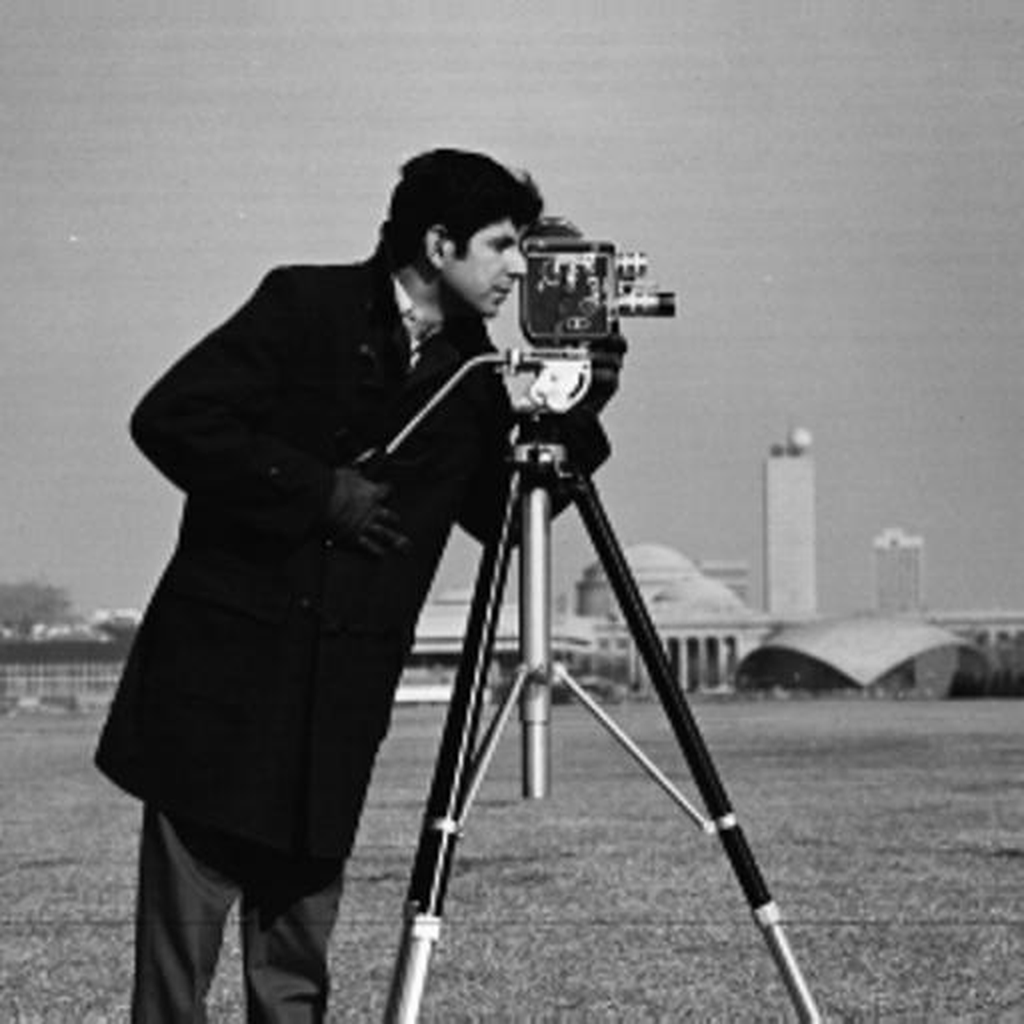

In [6]:
# ── 1. Increase size (scale ×2) ────────────────────
new_w = int(w * cx)
new_h = int(h * cy)

# Resize the image using PIL's built-in method
img_scaled = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
display(img_scaled)

In [7]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
img_scaled.save('task1_1_scaled.jpg')

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [8]:
f = img.transform(
    (w,h),
    Image.AFFINE,
    (-1,0,w,
     0,1,0),
)

In [9]:
f.save('task1_2_flipped.jpg')

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [10]:
# ── 2. Rotate 120 degrees ──────────────────────────
img_rotated = img.rotate(120,resample=Image.Resampling.BICUBIC, expand=True)
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
img_rotated.save('task1_2_rotated.jpg')

### 3. Shear

In [11]:
# -- c. Get the image dimensions ────────────────────
w, h = img.size

In [12]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5
shy = 0.5

In [13]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared = img.transform(
    (w,h),
    Image.AFFINE,
    (1, shx, 0,
     shy, 1, 0),
    resample=Image.Resampling.BICUBIC,
)

In [14]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared.save('task1_3_sheared.jpg')

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [15]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
arr = np.array(img)
negative_arr = 255 - arr
negative_img = Image.fromarray(negative_arr)
negative_img.save('task2_1_negative.jpg')  



In [16]:
# Method 2: PIL's ImageOps
from PIL import ImageOps
negative_img2 = ImageOps.invert(img)
negative_img2.save('task2_1_negative2.jpg') 

In [17]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)


# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr)
log_transformed_arr = Image.fromarray(np.uint8(log_transformed_arr))
log_transformed_arr.save('task2_2_log_transformed.jpg')

C:\Users\415\AppData\Local\Temp\ipykernel_15800\283304545.py:11: RuntimeWarning: divide by zero encountered in log
  log_transformed_arr = c * np.log(1 + arr)
C:\Users\415\AppData\Local\Temp\ipykernel_15800\283304545.py:12: RuntimeWarning: invalid value encountered in cast
  log_transformed_arr = Image.fromarray(np.uint8(log_transformed_arr))


In [18]:

# ── 3. Power-law / Gamma correction ───────────────
img_array = np.array(img).astype(float)
gamma = 0.5 
c = 1 
gamma_corrected = c * (img_array / 255.0) ** gamma
gamma_corrected = np.uint8(gamma_corrected * 255)
gamma_corrected_img = Image.fromarray(gamma_corrected)
gamma_corrected_img.save('task2_3_gamma_corrected.jpg') 